In [3]:
import cobra
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import sys
sys.path.append('../../../../code/')
import leakage, utils
import seaborn as sns

In [5]:
model = cobra.io.read_sbml_model('../../../../models/e_coli/momentiJO1366_modified.xml')
# model.reactions.DHAPT.knock_out()
# model.reactions.THRA.knock_out()
# model.reactions.THRA2.knock_out()
# model.reactions.F6PA_TG_forward.knock_out()
# Speculations
# model.reactions.PFL.knock_out()
#I'm more and more conviced that PFL is not active in aerobic conditions
# https://doi.org/10.1016/j.jbc.2021.101423

Adding exchange reaction EX_12ppd__R_e with default bounds for boundary metabolite: 12ppd__R_e.
Adding exchange reaction EX_12ppd__S_e with default bounds for boundary metabolite: 12ppd__S_e.
Adding exchange reaction EX_14glucan_e with default bounds for boundary metabolite: 14glucan_e.
Adding exchange reaction EX_15dap_e with default bounds for boundary metabolite: 15dap_e.
Adding exchange reaction EX_23camp_e with default bounds for boundary metabolite: 23camp_e.
Adding exchange reaction EX_23ccmp_e with default bounds for boundary metabolite: 23ccmp_e.
Adding exchange reaction EX_23cgmp_e with default bounds for boundary metabolite: 23cgmp_e.
Adding exchange reaction EX_23cump_e with default bounds for boundary metabolite: 23cump_e.
Adding exchange reaction EX_23dappa_e with default bounds for boundary metabolite: 23dappa_e.
Adding exchange reaction EX_26dap__M_e with default bounds for boundary metabolite: 26dap__M_e.
Adding exchange reaction EX_2ddglcn_e with default bounds for bo

In [6]:
solution = model.optimize()
print(model.summary())

Objective
1.0 BIOMASS_Ec_iJO1366_core_53p95M = 4.27672398810821

Uptake
------
    Metabolite          Reaction      Flux  C-Number C-Flux
     prot_pool       ER_pool_TG_     0.095         0  0.00%
LalaDgluMdap_e EX_LalaDgluMdap_e    0.1188        15  0.15%
    LalaLglu_e     EX_LalaLglu_e      2.19         8  1.50%
        acac_e         EX_acac_e     242.1         4 83.11%
         ade_e          EX_ade_e    0.8737         5  0.37%
      alaala_e       EX_alaala_e    0.1188         6  0.06%
      arg__L_e       EX_arg__L_e     1.265         6  0.65%
      asn__L_e       EX_asn__L_e     1.031         4  0.35%
      asp__L_e       EX_asp__L_e     1.031         4  0.35%
         btn_e          EX_btn_e 8.553E-06        10  0.00%
         ca2_e          EX_ca2_e   0.02226         0  0.00%
          cl_e           EX_cl_e   0.02226         0  0.00%
     cobalt2_e      EX_cobalt2_e 0.0001069         0  0.00%
         cu2_e          EX_cu2_e  0.003032         0  0.00%
      cys__L_e       

In [11]:
sp_dict = {}
for m in model.metabolites:
    if m.compartment =='c':
        if m.formula_weight and m.formula_weight < 350:
            raw_sp = solution.shadow_prices[m.id]
            calculated_sp = leakage.estimate_shadow_price_for_met(model, m, solution, delta = 0.01)
            sp_dict[m.id] = [raw_sp, calculated_sp]

/Users/snorre/miniconda3/lib/python3.12/site-packages/cobra/core/metabolite.py:191: UserWarning: The element 'R' does not appear in the periodic table
  warn(f"The element {e} does not appear in the periodic table")
/Users/snorre/miniconda3/lib/python3.12/site-packages/cobra/core/metabolite.py:191: UserWarning: The element 'X' does not appear in the periodic table
  warn(f"The element {e} does not appear in the periodic table")


In [12]:
sp_df = pd.DataFrame(sp_dict).T
sp_df.columns = ['From solver', 'Brute force']

In [13]:
sp_df['Diff'] = (sp_df['From solver']-sp_df['Brute force']).abs()
sel = sp_df.loc[sp_df['Diff'] > 1e-2, :]

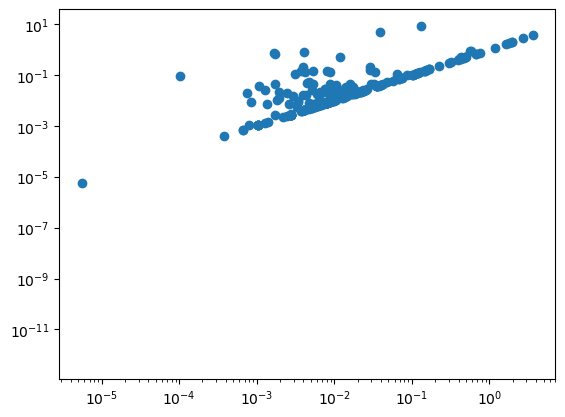

In [ ]:
plt.plot(-1*sp_df['From solver'], -1*sp_df['Brute force'], 'o')
plt.yscale('log')
plt.xscale('log')